# 🧮 Math Refresher — Linear Algebra, Probability & Calculus for ML

This is the last Foundation topic, and the one every Classical ML algorithm ahead ultimately reduces to. Linear/Logistic Regression is linear algebra + calculus. Naive Bayes is probability theory. Gradient Boosting is calculus (gradients) applied repeatedly. This notebook builds working intuition for all three pillars, with code demonstrations tied directly to what's coming next.

📖 Full mathematical explanation and formulas: [README.md](README.md)


## 1. Linear Algebra — Vectors & Norms

A **norm** measures a vector's "size." The two you'll see constantly:

- **L2 norm** (Euclidean length) — used in Ridge regression's penalty, KNN's distance metric, standard deviation
- **L1 norm** (Manhattan/taxicab length) — used in Lasso regression's penalty, robust to outliers

Formulas and geometric intuition are in the README; here we compute both directly.


Vector: [3 4]
L2 norm (Euclidean length): 5.0
L1 norm (Manhattan length): 7.0


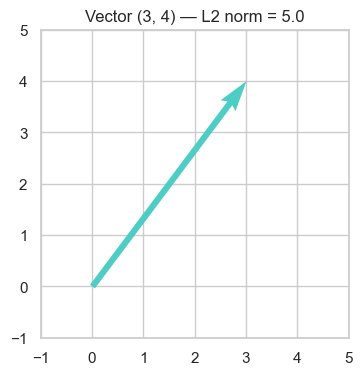

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
np.random.seed(42)

v = np.array([3, 4])

l2_norm = np.linalg.norm(v, ord=2)   # sqrt(3^2 + 4^2) = 5, the classic 3-4-5 triangle
l1_norm = np.linalg.norm(v, ord=1)   # |3| + |4| = 7

print(f"Vector: {v}")
print(f"L2 norm (Euclidean length): {l2_norm}")
print(f"L1 norm (Manhattan length): {l1_norm}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.quiver(0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1, color="#4ecdc4", width=0.02)
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.set_title(f"Vector (3, 4) — L2 norm = {l2_norm:.1f}")
ax.set_aspect("equal")
plt.show()


## 2. Linear Algebra — Matrix Inverse & Solving Linear Systems

Solving $A\mathbf{x} = \mathbf{b}$ for $\mathbf{x}$ is the core computation behind the **Normal Equation**, the closed-form solution to Linear Regression covered in the very next repo. We solve it two ways — via explicit matrix inversion, and via NumPy's more numerically stable solver — and confirm they agree.


In [2]:
A = np.array([[2, 1], [1, 3]], dtype=float)
b = np.array([8, 13], dtype=float)

# Method 1: explicit inverse (educational, but numerically less stable for larger systems)
x_via_inverse = np.linalg.inv(A) @ b

# Method 2: np.linalg.solve — what you should actually use in practice (faster, more stable)
x_via_solve = np.linalg.solve(A, b)

print("Solution via explicit inverse:", x_via_inverse)
print("Solution via np.linalg.solve :", x_via_solve)
print("Verification A @ x == b?     ", np.allclose(A @ x_via_solve, b))

print("\ndeterminant(A) =", np.linalg.det(A), " (non-zero -> A is invertible, a unique solution exists)")


Solution via explicit inverse: [2.2 3.6]
Solution via np.linalg.solve : [2.2 3.6]
Verification A @ x == b?      True

determinant(A) = 5.000000000000001  (non-zero -> A is invertible, a unique solution exists)


## 3. Linear Algebra — Eigenvalues & Eigenvectors

An eigenvector of $A$ is a direction that $A$ only *stretches*, never rotates. This is the mathematical engine behind **PCA** (Unsupervised learning, later in Classical ML): PCA finds the eigenvectors of a covariance matrix, which turn out to be the directions of maximum variance in the data.


Eigenvalues: [5.56155281 1.43844719]
Eigenvectors (as columns):
 [[ 0.78820544 -0.61541221]
 [ 0.61541221  0.78820544]]

Eigenpair 0: A@v = [4.384 3.423], lambda*v = [4.384 3.423], match = True

Eigenpair 1: A@v = [-0.885  1.134], lambda*v = [-0.885  1.134], match = True


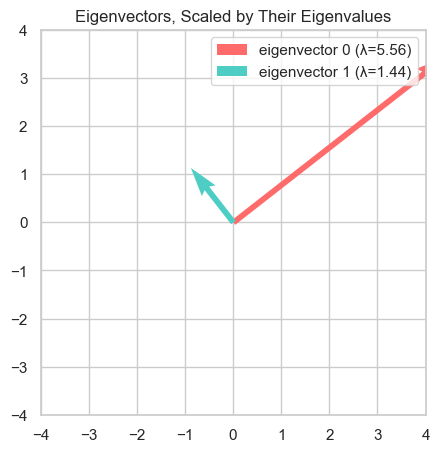

In [3]:
cov_like_matrix = np.array([[4, 2], [2, 3]], dtype=float)   # symmetric, like a real covariance matrix

eigenvalues, eigenvectors = np.linalg.eig(cov_like_matrix)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors (as columns):\n", eigenvectors)

# Verify the defining property: A @ v == lambda * v for each eigenpair
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lhs = cov_like_matrix @ v
    rhs = eigenvalues[i] * v
    print(f"\nEigenpair {i}: A@v = {lhs.round(3)}, lambda*v = {rhs.round(3)}, match = {np.allclose(lhs, rhs)}")

fig, ax = plt.subplots(figsize=(5, 5))
origin = np.zeros(2)
colors = ["#ff6b6b", "#4ecdc4"]
for i in range(2):
    v = eigenvectors[:, i] * eigenvalues[i]
    ax.quiver(*origin, *v, angles="xy", scale_units="xy", scale=1, color=colors[i],
               label=f"eigenvector {i} (λ={eigenvalues[i]:.2f})", width=0.015)
ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.legend()
ax.set_title("Eigenvectors, Scaled by Their Eigenvalues")
ax.set_aspect("equal")
plt.show()


## 4. Probability — Common Distributions

Every classical ML algorithm implicitly assumes something about how data is distributed. Naive Bayes assumes (often) a Gaussian per feature per class; logistic regression's output is interpreted via the Bernoulli distribution. Visualizing these builds intuition for those assumptions.


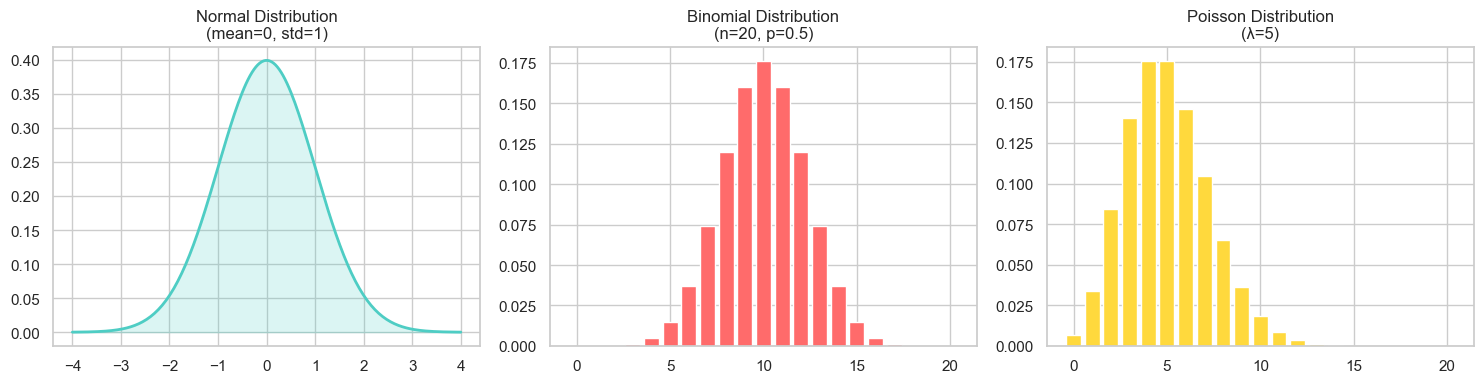

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Normal (Gaussian) — the most common assumption in classical ML
x_range = np.linspace(-4, 4, 200)
axes[0].plot(x_range, stats.norm.pdf(x_range, loc=0, scale=1), color="#4ecdc4", linewidth=2)
axes[0].set_title("Normal Distribution\n(mean=0, std=1)")
axes[0].fill_between(x_range, stats.norm.pdf(x_range), alpha=0.2, color="#4ecdc4")

# Binomial — discrete, e.g. "successes out of n trials" (relevant to classification accuracy)
k_range = np.arange(0, 21)
axes[1].bar(k_range, stats.binom.pmf(k_range, n=20, p=0.5), color="#ff6b6b")
axes[1].set_title("Binomial Distribution\n(n=20, p=0.5)")

# Poisson — discrete, e.g. "events per time window" (relevant to count-based features)
axes[2].bar(k_range, stats.poisson.pmf(k_range, mu=5), color="#ffd93d")
axes[2].set_title("Poisson Distribution\n(λ=5)")

plt.tight_layout()
plt.show()


## 5. Probability — Bayes' Theorem

Bayes' theorem is the entire foundation of the **Naive Bayes classifier**, covered later in Classical ML. We verify it numerically with a classic diagnostic-test example: a disease affects 1% of a population, and a test is 95% accurate — what's the real chance you have the disease given a positive test?


In [5]:
p_disease = 0.01                 # P(Disease) -- prior
p_pos_given_disease = 0.95       # P(Positive | Disease) -- test sensitivity
p_pos_given_healthy = 0.05       # P(Positive | Healthy) -- false positive rate

p_healthy = 1 - p_disease
p_positive = p_pos_given_disease * p_disease + p_pos_given_healthy * p_healthy   # law of total probability

# Bayes' theorem: P(Disease | Positive) = P(Positive | Disease) * P(Disease) / P(Positive)
p_disease_given_pos = (p_pos_given_disease * p_disease) / p_positive

print(f"P(Positive test)              = {p_positive:.4f}")
print(f"P(Disease | Positive test)    = {p_disease_given_pos:.4f}  ({p_disease_given_pos*100:.1f}%)")
print("\n-> Even with a 95%-accurate test, a positive result only means ~16% real risk,")
print("   because the disease is rare (a low PRIOR dominates the result). This exact")
print("   prior-times-likelihood mechanism is what Naive Bayes computes per class, per prediction.")


P(Positive test)              = 0.0590
P(Disease | Positive test)    = 0.1610  (16.1%)

-> Even with a 95%-accurate test, a positive result only means ~16% real risk,
   because the disease is rare (a low PRIOR dominates the result). This exact
   prior-times-likelihood mechanism is what Naive Bayes computes per class, per prediction.


## 6. Statistics — Covariance Matrix & The Central Limit Theorem

The covariance matrix generalizes topic 02's Pearson correlation to every feature pair at once — the same matrix PCA decomposes (see the eigenvector section above). We then demonstrate the **Central Limit Theorem (CLT)**: no matter how skewed the original data is, the distribution of *sample means* becomes approximately Normal as sample size grows — the theoretical justification for why so many statistical methods assume normality even when raw data doesn't look normal.


Sample covariance matrix:
 [[2.7743408  1.39693585]
 [1.39693585 1.94631702]]


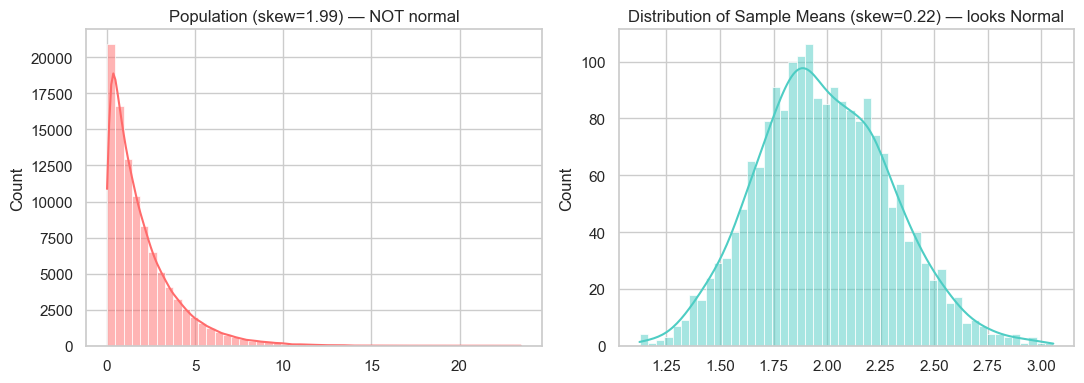

In [6]:
X = np.random.multivariate_normal(mean=[0, 0], cov=[[3, 1.5], [1.5, 2]], size=500)
cov_matrix = np.cov(X, rowvar=False)
print("Sample covariance matrix:\n", cov_matrix)

# CLT demonstration: repeatedly sample means from a heavily skewed (exponential) population
population = np.random.exponential(scale=2, size=100_000)
sample_means = [np.mean(np.random.choice(population, size=40, replace=False)) for _ in range(2000)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(population, bins=50, ax=axes[0], color="#ff6b6b", kde=True)
axes[0].set_title(f"Population (skew={pd.Series(population).skew():.2f}) — NOT normal")

sns.histplot(sample_means, bins=50, ax=axes[1], color="#4ecdc4", kde=True)
axes[1].set_title(f"Distribution of Sample Means (skew={pd.Series(sample_means).skew():.2f}) — looks Normal")

plt.tight_layout()
plt.show()


## 7. Calculus — Derivatives, Gradients & Gradient Descent

**Gradient descent** is how almost every ML model (Logistic Regression, Neural Networks, Gradient Boosting) actually learns: repeatedly step in the direction that most reduces a loss function. We minimize a simple bowl-shaped function $f(x) = (x-3)^2 + 2$ by hand-rolled gradient descent, and watch it converge to the true minimum at $x=3$.


Started at x = -5.0, converged to x = 2.9901 (true minimum is x = 3)


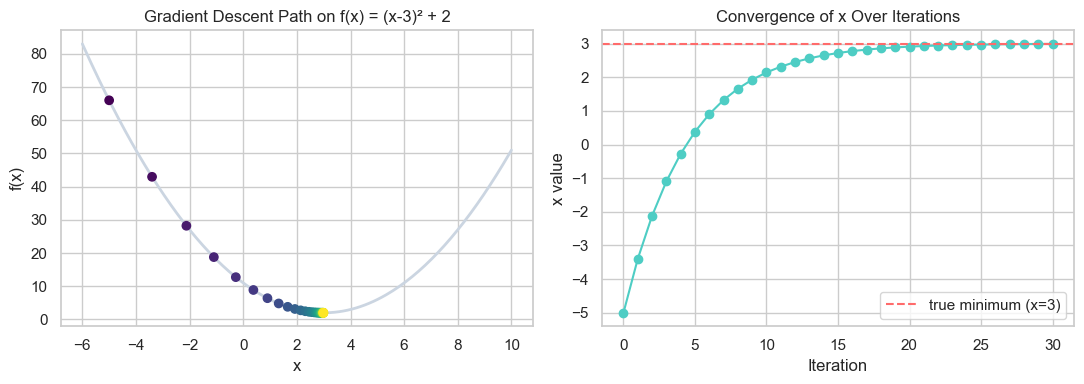

In [7]:
def f(x):
    return (x - 3) ** 2 + 2

def gradient(x):
    return 2 * (x - 3)   # derivative of f, computed analytically

x_current = -5.0          # start far from the minimum
learning_rate = 0.1
history = [x_current]

for step in range(30):
    grad = gradient(x_current)
    x_current = x_current - learning_rate * grad   # the gradient descent update rule
    history.append(x_current)

print(f"Started at x = {history[0]}, converged to x = {history[-1]:.4f} (true minimum is x = 3)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x_plot = np.linspace(-6, 10, 200)
axes[0].plot(x_plot, f(x_plot), color="#cbd5e1", linewidth=2, zorder=1)
axes[0].scatter(history, [f(x) for x in history], c=range(len(history)), cmap="viridis", zorder=2)
axes[0].set_title("Gradient Descent Path on f(x) = (x-3)² + 2")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")

axes[1].plot(history, marker="o", color="#4ecdc4")
axes[1].axhline(3, color="#ff6b6b", linestyle="--", label="true minimum (x=3)")
axes[1].set_title("Convergence of x Over Iterations")
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("x value")
axes[1].legend()

plt.tight_layout()
plt.show()


## ✅ Key Takeaways

- **Linear algebra** (vectors, matrix inversion, eigenvectors) is the data structure and the solver behind Linear Regression's normal equation and PCA's variance-maximizing directions.
- **Probability** (distributions, Bayes' theorem) is the direct foundation of Naive Bayes, and the reasoning tool behind every "how confident is this prediction" question.
- **The Central Limit Theorem** is why so many statistical procedures (confidence intervals, hypothesis tests) can assume normality even on real-world, non-normal data — as long as they operate on sample means with a reasonably large sample size.
- **Gradient descent**, demonstrated here on a toy 1D function, is *exactly* the same update rule (scaled up to many parameters) that trains Logistic Regression, Neural Networks, and Gradient Boosting models later in this series.
- Every one of these five concepts will be explicitly referenced again by name in the Classical ML notebooks — this topic is the payoff for reading the math sections carefully.

**Foundation complete.** Next: the [Classical ML repository](https://github.com/mdnuruzzamanKALLOL/Statistical-Machine-Learning-Classical-ML) — starting with Regression, where the normal equation from section 2 makes its first real appearance.
